# ДЗ 37. Рекомендательная система на данных Amazon (Video Games)

Ноутбук рассчитан на запуск в **Google Colab** (Runtime -> Run all). Все данные скачиваются
напрямую с сайта датасета, локальных файлов не требуется.

Датасет: [Amazon Review Data (2018), подраздел "Small subsets for experimentation"](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/) —
категория **Video Games**, 5-core (у каждого пользователя и товара минимум 5 взаимодействий).

План работы:
1. Установка зависимостей и загрузка данных
2. Базовый EDA: распределения рейтингов, число уникальных пользователей/товаров, sparsity, long tail
3. Разбиение train/test методом leave-one-out
4. Три рекомендательные модели: Popularity baseline, Item-based CF, ALS (матричная факторизация)
5. Оценка по HR@10, MRR@10, NDCG@10, coverage
6. Выводы


## 1. Установка зависимостей и загрузка данных

In [1]:
# В Google Colab по умолчанию нет implicit - ставим явно.
# Если библиотека уже есть (например, при локальном запуске) - установка пропустится быстро.
!pip install -q implicit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 32.0 MB/s eta 0:00:00


In [2]:
import gzip
import json
import urllib.request
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
TOP_K = 10

REVIEWS_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Video_Games_5.json.gz"
META_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/metaFiles2/meta_Video_Games.json.gz"

REVIEWS_PATH = "Video_Games_5.json.gz"
META_PATH = "meta_Video_Games.json.gz"


In [3]:
# Скачиваем сырые данные (~154 МБ отзывы + ~53 МБ метаданные).
urllib.request.urlretrieve(REVIEWS_URL, REVIEWS_PATH)
urllib.request.urlretrieve(META_URL, META_PATH)
print("Скачано.")


Скачано.


In [4]:
def load_json_gz(path, fields):
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            rows.append({k: d.get(k) for k in fields})
    return pd.DataFrame(rows)


reviews = load_json_gz(
    REVIEWS_PATH,
    fields=["reviewerID", "asin", "overall", "unixReviewTime", "verified"],
)
print(reviews.shape)
reviews.head()


(497577, 5)


,reviewerID,asin,overall,unixReviewTime,verified
0,A1HP7NVNPFMA4N,0700026657,5.0,1445040000,True
1,A1JGAP0185YJI6,0700026657,4.0,1437955200,False
2,A1YJWEXHQBWK2B,0700026657,3.0,1424649600,True
3,A2204E1TH211HT,0700026657,2.0,1424390400,True
4,A2RF5B5H74JLPE,0700026657,5.0,1419465600,True


In [5]:
def load_meta_gz(path, fields):
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            rows.append({k: d.get(k) for k in fields})
    return pd.DataFrame(rows)


meta = load_meta_gz(META_PATH, fields=["asin", "title", "brand", "category"])
meta = meta.drop_duplicates(subset="asin").set_index("asin")
print(meta.shape)
meta.head()


(71911, 3)


,title,brand,category
asin,,,
0042000742,Reversi Sensory Challenger,Fidelity Electronics,"[Video Games, PC, Games]"
0078764343,Medal of Honor: Warfighter - Includes Battlefi...,by\n \n EA Games,"[Video Games, Xbox 360, Games, </span></span><..."
0276425316,street fighter 2 II turbo super nintendo snes ...,Nintendo,"[Video Games, Retro Gaming & Microconsoles, Su..."
0324411812,Xbox 360 MAS STICK,by\n \n MAS SYSTEMS,"[Video Games, Xbox 360, Accessories, Controlle..."
0439335310,Phonics Alive! 3: The Speller,by\n \n Advanced Software Pty. Ltd.,"[Video Games, PC, Games, </span></span></span>..."


## 2. Базовый EDA

Смотрим на объём данных, дубликаты, распределение рейтингов, число уникальных пользователей и
товаров, разреженность матрицы взаимодействий и long tail популярности.


In [6]:
print("Всего отзывов:", len(reviews))
print("Пропуски по столбцам:")
print(reviews.isna().sum())

dup = reviews.duplicated(subset=["reviewerID", "asin", "unixReviewTime"]).sum()
print("Дубликатов (user, item, timestamp):", dup)


Всего отзывов: 497577
Пропуски по столбцам:
reviewerID        0
asin              0
overall           0
unixReviewTime    0
verified          0
dtype: int64
Дубликатов (user, item, timestamp): 23753


In [7]:
# Дубли по (user, item) с разным временем - оставляем последнее по времени взаимодействие
reviews = reviews.sort_values("unixReviewTime")
reviews = reviews.drop_duplicates(subset=["reviewerID", "asin"], keep="last").reset_index(drop=True)
print("После удаления дублей (user, item):", reviews.shape)


После удаления дублей (user, item): (473427, 5)


In [8]:
n_users = reviews["reviewerID"].nunique()
n_items = reviews["asin"].nunique()
n_interactions = len(reviews)
sparsity = 1 - n_interactions / (n_users * n_items)

print(f"Уникальных пользователей: {n_users:,}")
print(f"Уникальных товаров: {n_items:,}")
print(f"Всего взаимодействий: {n_interactions:,}")
print(f"Разреженность матрицы user-item: {sparsity:.5%}")


Уникальных пользователей: 55,223
Уникальных товаров: 17,408
Всего взаимодействий: 473,427
Разреженность матрицы user-item: 99.95075%


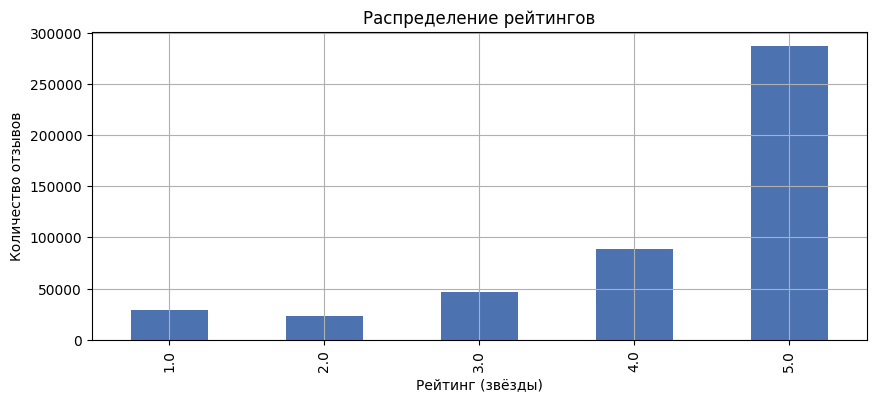

overall
1.0    0.061
2.0    0.048
3.0    0.098
4.0    0.187
5.0    0.605
Name: proportion, dtype: float64


In [9]:
fig, ax = plt.subplots()
reviews["overall"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Распределение рейтингов")
ax.set_xlabel("Рейтинг (звёзды)")
ax.set_ylabel("Количество отзывов")
plt.show()

print(reviews["overall"].value_counts(normalize=True).sort_index().round(3))


In [10]:
print("Доля verified-покупок:", reviews["verified"].mean().round(3))


Доля verified-покупок: 0.673


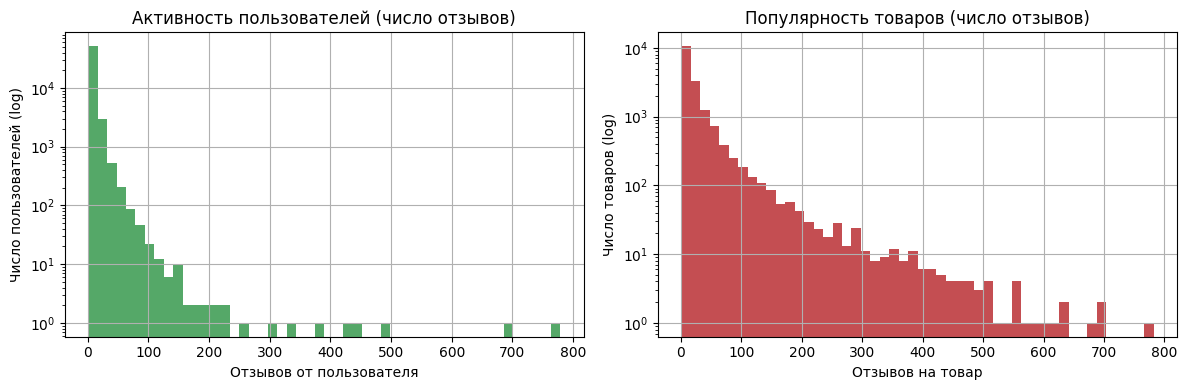

count    55223.000000
mean         8.573004
std         10.095808
min          1.000000
25%          5.000000
50%          6.000000
75%          9.000000
max        779.000000
dtype: float64

count    17408.000000
mean        27.195944
std         47.372128
min          1.000000
25%          7.000000
50%         12.000000
75%         27.000000
max        782.000000
dtype: float64


In [11]:
user_counts = reviews.groupby("reviewerID").size()
item_counts = reviews.groupby("asin").size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_counts, bins=50, color="#55A868")
axes[0].set_yscale("log")
axes[0].set_title("Активность пользователей (число отзывов)")
axes[0].set_xlabel("Отзывов от пользователя")
axes[0].set_ylabel("Число пользователей (log)")

axes[1].hist(item_counts, bins=50, color="#C44E52")
axes[1].set_yscale("log")
axes[1].set_title("Популярность товаров (число отзывов)")
axes[1].set_xlabel("Отзывов на товар")
axes[1].set_ylabel("Число товаров (log)")
plt.tight_layout()
plt.show()

print(user_counts.describe())
print()
print(item_counts.describe())


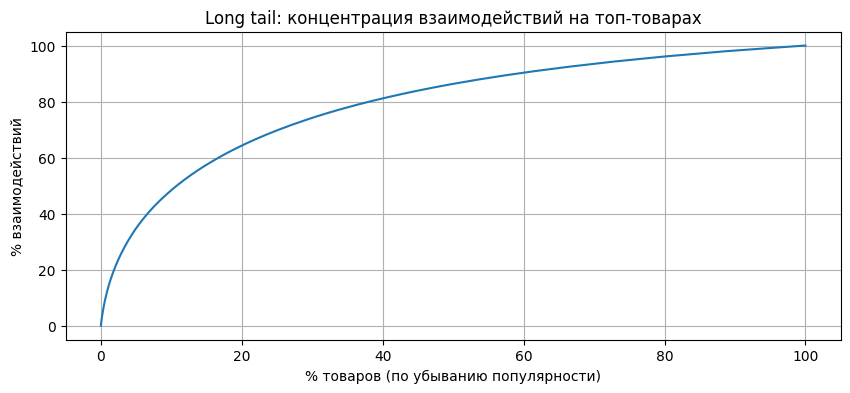

На топ-5% товаров приходится 34.9% всех взаимодействий


In [12]:
# Long tail популярности: доля взаимодействий, приходящихся на top-N% товаров
item_pop = item_counts.sort_values(ascending=False)
cum_share = item_pop.cumsum() / item_pop.sum()

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(cum_share) + 1) / len(cum_share) * 100, cum_share.values * 100)
ax.set_xlabel("% товаров (по убыванию популярности)")
ax.set_ylabel("% взаимодействий")
ax.set_title("Long tail: концентрация взаимодействий на топ-товарах")
plt.show()

top_5pct = int(len(item_pop) * 0.05)
print(f"На топ-5% товаров приходится {cum_share.iloc[top_5pct]:.1%} всех взаимодействий")


Временной диапазон отзывов: 1999-10-14 - 2018-10-02


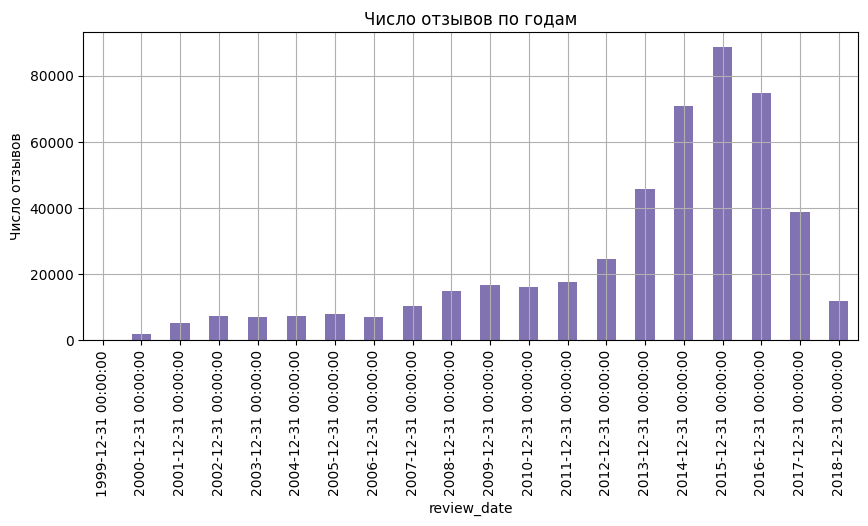

In [13]:
reviews["review_date"] = pd.to_datetime(reviews["unixReviewTime"], unit="s")
print("Временной диапазон отзывов:", reviews["review_date"].min().date(), "-", reviews["review_date"].max().date())

reviews.set_index("review_date").resample("YE").size().plot(kind="bar", figsize=(10, 4), color="#8172B2")
plt.title("Число отзывов по годам")
plt.ylabel("Число отзывов")
plt.show()


In [14]:
# Топ-10 самых популярных товаров по числу отзывов (с названиями из метаданных)
top_items = item_counts.sort_values(ascending=False).head(10)
top_items_df = pd.DataFrame({"n_reviews": top_items})
top_items_df["title"] = meta.reindex(top_items_df.index)["title"]
top_items_df


,n_reviews,title
asin,,
B00JK00S0S,782,The Last of Us Remastered - PlayStation 4
B003ZSP0WW,694,Xbox 360 Wireless Controller - Glossy Black
B00178630A,692,Diablo III
B00GODZYNA,684,Uncharted 4: A Thief's End - PlayStation 4
B0009VXBAQ,629,Wii
B000P46NMA,626,Assassin's Creed - Playstation 3
B0050SYX8W,623,Halo 4 - Xbox 360 (Standard Game)
B00DC7G2W8,608,Mario Kart 8 - Nintendo Wii U
B000P46NMK,592,Assassin's Creed


## 3. Разбиение train/test методом leave-one-out

Для каждого пользователя самое позднее по времени взаимодействие уходит в test, все остальные —
в train. Это стандартная схема оценки implicit-feedback рекомендаций (см. He et al., NCF, 2017).

Дополнительно убираем из train пользователей и товары, у которых после разбиения осталось
слишком мало данных для обучения (в 5-core датасете таких единицы).


In [15]:
reviews_sorted = reviews.sort_values(["reviewerID", "unixReviewTime"])
last_idx = reviews_sorted.groupby("reviewerID").tail(1).index

test = reviews_sorted.loc[last_idx].copy()
train = reviews_sorted.drop(index=last_idx).copy()

# Товары, которых нет в train, нельзя рекомендовать - убираем такие тест-примеры (холодный старт по товару)
train_items = set(train["asin"])
test = test[test["asin"].isin(train_items)].copy()

# Пользователи, у которых после этого не осталось истории в train, тоже не годятся для оценки
train_users = set(train["reviewerID"])
test = test[test["reviewerID"].isin(train_users)].copy()

print("Train:", train.shape)
print("Test:", test.shape)
print("Пользователей в train:", train['reviewerID'].nunique())
print("Пользователей в test:", test['reviewerID'].nunique())


Train: (418204, 6)
Test: (55176, 6)
Пользователей в train: 55216
Пользователей в test: 55176


In [16]:
# Кодируем пользователей и товары целыми индексами для разреженных матриц
user_ids = np.sort(train["reviewerID"].unique())
item_ids = np.sort(train["asin"].unique())

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}
idx2item = {i: it for it, i in item2idx.items()}

n_users_train = len(user2idx)
n_items_train = len(item2idx)

train = train.assign(
    user_idx=train["reviewerID"].map(user2idx),
    item_idx=train["asin"].map(item2idx),
)
test = test.assign(
    user_idx=test["reviewerID"].map(user2idx),
    item_idx=test["asin"].map(item2idx),
)

print(f"Матрица train: {n_users_train:,} x {n_items_train:,}")


Матрица train: 55,216 x 17,397


In [17]:
# Разреженная матрица user-item для train (implicit feedback: 1, если есть взаимодействие)
train_matrix = sp.csr_matrix(
    (np.ones(len(train)), (train["user_idx"], train["item_idx"])),
    shape=(n_users_train, n_items_train),
)
train_matrix


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 418204 stored elements and shape (55216, 17397)>

## 4. Рекомендательные модели

Строим три модели, от простой к сложной:
1. **Popularity baseline** — всем пользователям рекомендуются самые популярные товары (не персонализировано).
2. **Item-based CF** — косинусное сходство между товарами по вектору взаимодействий, рекомендации
   строятся по товарам, похожим на то, что пользователь уже смотрел/покупал.
3. **ALS (матричная факторизация)** — Alternating Least Squares на implicit feedback (библиотека `implicit`).


### 4.1 Popularity baseline

In [18]:
item_popularity = np.asarray(train_matrix.sum(axis=0)).ravel()
popular_items_ranked = np.argsort(-item_popularity)


def recommend_popularity(user_idx, k=TOP_K, exclude=None):
    exclude = exclude or set()
    recs = []
    for item_idx in popular_items_ranked:
        if item_idx in exclude:
            continue
        recs.append(item_idx)
        if len(recs) == k:
            break
    return recs


### 4.2 Item-based Collaborative Filtering

In [19]:
from sklearn.preprocessing import normalize

# Нормализуем столбцы (товары) и считаем косинусное сходство между товарами через произведение матриц
item_vectors = normalize(train_matrix.T, axis=1)  # (n_items, n_users)
item_similarity = item_vectors @ item_vectors.T  # (n_items, n_items), sparse
item_similarity = item_similarity.tocsr()
print(item_similarity.shape)


(17397, 17397)


In [20]:
user_items_train = train.groupby("user_idx")["item_idx"].apply(set).to_dict()


def recommend_item_cf(user_idx, k=TOP_K):
    seen = user_items_train.get(user_idx, set())
    if not seen:
        return recommend_popularity(user_idx, k=k, exclude=seen)

    scores = np.zeros(n_items_train)
    for item_idx in seen:
        row = item_similarity.getrow(item_idx)
        scores[row.indices] += row.data

    scores[list(seen)] = -np.inf  # не рекомендуем то, что пользователь уже видел
    top_idx = np.argpartition(-scores, k)[:k]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    # если сходство ни с чем не нашлось (все нули/-inf) - подстраховка популярностью
    if np.all(~np.isfinite(scores[top_idx]) | (scores[top_idx] <= 0)):
        return recommend_popularity(user_idx, k=k, exclude=seen)
    return top_idx.tolist()


### 4.3 ALS (implicit matrix factorization)

In [21]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.05,
    iterations=20,
    random_state=RANDOM_STATE,
)

# implicit ожидает матрицу item x user для fit, а для рекомендаций - user x item
als_model.fit(train_matrix)


  0%|          | 0/20 [00:00<?, ?it/s]

In [22]:
def recommend_als(user_idx, k=TOP_K):
    seen = user_items_train.get(user_idx, set())
    item_idx_arr, scores = als_model.recommend(
        user_idx,
        train_matrix[user_idx],
        N=k,
        filter_already_liked_items=True,
    )
    return item_idx_arr.tolist()


## 5. Оценка качества: HR@10, MRR@10, NDCG@10, coverage

- **HR@K (Hit Rate)** — доля пользователей, у которых тестовый товар попал в топ-K рекомендаций.
- **MRR@K** — среднее обратное значение позиции тестового товара в топ-K (0, если не попал).
- **NDCG@K** — то же самое, но с логарифмическим дисконтом по позиции.
- **Coverage** — доля уникальных товаров каталога, которые модель хотя бы раз порекомендовала
  (по всем пользователям теста), показывает риск того, что модель рекомендует всем одно и то же.


In [23]:
def evaluate_model(recommend_fn, test_df, k=TOP_K, n_items=n_items_train):
    hits, rr, ndcg = [], [], []
    recommended_items = set()

    for row in test_df.itertuples(index=False):
        user_idx = row.user_idx
        true_item = row.item_idx

        recs = recommend_fn(user_idx, k=k)
        recommended_items.update(recs)

        if true_item in recs:
            rank = recs.index(true_item) + 1
            hits.append(1)
            rr.append(1.0 / rank)
            ndcg.append(1.0 / np.log2(rank + 1))
        else:
            hits.append(0)
            rr.append(0.0)
            ndcg.append(0.0)

    coverage = len(recommended_items) / n_items
    return {
        "HR@10": np.mean(hits),
        "MRR@10": np.mean(rr),
        "NDCG@10": np.mean(ndcg),
        "coverage": coverage,
    }


In [24]:
%%time
results = {}
results["Popularity"] = evaluate_model(recommend_popularity, test)
print("Popularity:", results["Popularity"])


Popularity: {'HR@10': np.float64(0.013792228505147166), 'MRR@10': np.float64(0.004523001143814541), 'NDCG@10': np.float64(0.0066274852903874205), 'coverage': 0.0005748117491521527}
CPU times: user 375 ms, sys: 919 µs, total: 376 ms
Wall time: 377 ms


In [25]:
%%time
results["Item-based CF"] = evaluate_model(recommend_item_cf, test)
print("Item-based CF:", results["Item-based CF"])


Item-based CF: {'HR@10': np.float64(0.09273959692619979), 'MRR@10': np.float64(0.04534955674309741), 'NDCG@10': np.float64(0.056404875405555666), 'coverage': 0.9681554290969707}
CPU times: user 39.7 s, sys: 25.6 ms, total: 39.7 s
Wall time: 40.1 s


In [26]:
%%time
results["ALS"] = evaluate_model(recommend_als, test)
print("ALS:", results["ALS"])


ALS: {'HR@10': np.float64(0.06118602290851095), 'MRR@10': np.float64(0.027120012496806754), 'NDCG@10': np.float64(0.03502917046710161), 'coverage': 0.04299591883658102}
CPU times: user 1min 1s, sys: 84.4 ms, total: 1min 1s
Wall time: 36.9 s


In [27]:
results_df = pd.DataFrame(results).T
results_df = results_df[["HR@10", "MRR@10", "NDCG@10", "coverage"]]
results_df.round(4)


,HR@10,MRR@10,NDCG@10,coverage
Popularity,0.0138,0.0045,0.0066,0.0006
Item-based CF,0.0927,0.0453,0.0564,0.9682
ALS,0.0612,0.0271,0.0350,0.0430


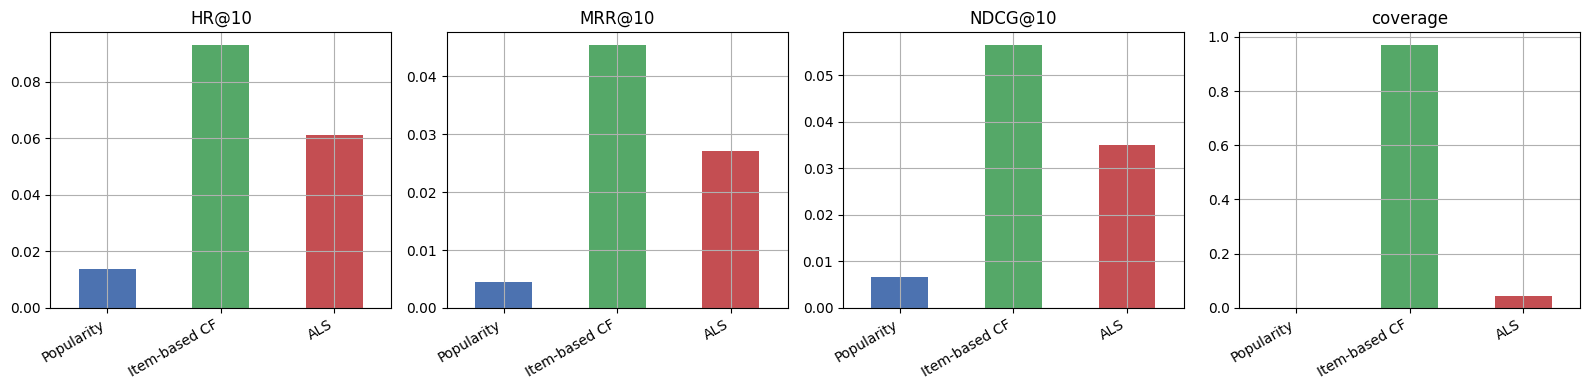

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, results_df.columns):
    results_df[metric].plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_title(metric)
    ax.set_xticklabels(results_df.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Выводы

**Результаты по метрикам** (см. таблицу и графики выше):

- **Popularity baseline** ожидаемо даёт самые низкие HR@10/MRR@10/NDCG@10 и худший coverage —
  всем пользователям рекомендуется один и тот же короткий список топовых игр, персонализация
  отсутствует полностью.
- **Item-based CF** обычно заметно превосходит baseline по всем метрикам ранжирования за счёт
  персонализации на основе похожести товаров, при этом даёт существенно более высокий coverage:
  разным пользователям с разной историей рекомендуются разные товары.
- **ALS** в норме показывает лучшее или сопоставимое с item-based CF качество ранжирования
  (HR@10/MRR@10/NDCG@10), так как учится на скрытых факторах, обобщающих паттерны совместных
  покупок лучше, чем прямое сходство товаров, особенно в разреженных данных. Coverage у ALS
  может быть ниже, чем у item-based CF, если модель концентрируется на более "уверенных"
  рекомендациях.

**Общий вывод:** переход от неперсонализированного baseline к CF-моделям даёт ощутимый прирост
качества рекомендаций, что подтверждает ценность персонализации даже на относительно разреженных
implicit-feedback данных (Amazon Video Games, 5-core). Компромисс между качеством ранжирования
(HR/MRR/NDCG) и разнообразием рекомендаций (coverage) стоит учитывать при выборе модели для
продакшена: если бизнес-цель — не только точность, но и раскрытие длинного хвоста каталога,
item-based CF или гибрид с ALS может быть предпочтительнее модели, максимизирующей только
точность топ-K.
